#  Notebook 1 · Khám phá Dữ liệu & Tiền xử lý Nâng cao

**Mục tiêu:** Khám phá, làm sạch và chuẩn hóa dữ liệu thô trước khi đưa vào pipeline huấn luyện.  
Pipeline tiền xử lý bao gồm: phân tích phân bố lớp → loại bỏ ảnh trùng (MD5) → lọc nhiễu (σ-threshold) → tăng cường độ tương phản (CLAHE) → chuẩn hóa kích thước (Letterbox 224 × 224).

---

| Bước | Kỹ thuật | Mục đích |
|:----:|----------|----------|
| 1 | **EDA** | Trực quan hóa phân bố lớp |
| 2 | **Deduplication (MD5)** | Loại bỏ ảnh trùng, tránh data leakage |
| 3 | **Noise Filtering (σ)** | Loại bỏ ảnh quá nhiễu, cải thiện chất lượng |
| 4 | **CLAHE + Letterbox** | Tăng tương phản & chuẩn hóa kích thước |


In [1]:
import os
import glob
import cv2
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from skimage.restoration import estimate_sigma
import albumentations as A
import shutil

# ----- CẤU HÌNH ĐƯỜNG DẪN -----
CURRENT_DIR = os.getcwd()
if os.path.basename(CURRENT_DIR) == 'notebooks':
    BASE_DIR = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
else:
    BASE_DIR = CURRENT_DIR

RAW_DATA_DIR = os.path.join(BASE_DIR, 'dataset')
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, 'dataset', 'processed_dataset')

CLASSES = ['not_smoking', 'smoking'] # Alphabetical order for consistency
TARGET_SIZE = (224, 224)

print(f"Thư mục dự án: {BASE_DIR}")
print(f"Dữ liệu thô tại: {RAW_DATA_DIR}")
print(f"Dữ liệu sau khi xử lý sẽ lưu tại: {PROCESSED_DATA_DIR}")

Thư mục dự án: d:\Dev\smoker_detection
Dữ liệu thô tại: d:\Dev\smoker_detection\dataset
Dữ liệu sau khi xử lý sẽ lưu tại: d:\Dev\smoker_detection\dataset\processed_dataset


## 1 · Khám phá Dữ liệu (EDA)

> Phân tích phân bố số lượng ảnh theo từng lớp trong tập dữ liệu thô.  
> **Mục tiêu:** Phát hiện mất cân bằng lớp (class imbalance) để xử lý phù hợp ở bước huấn luyện.


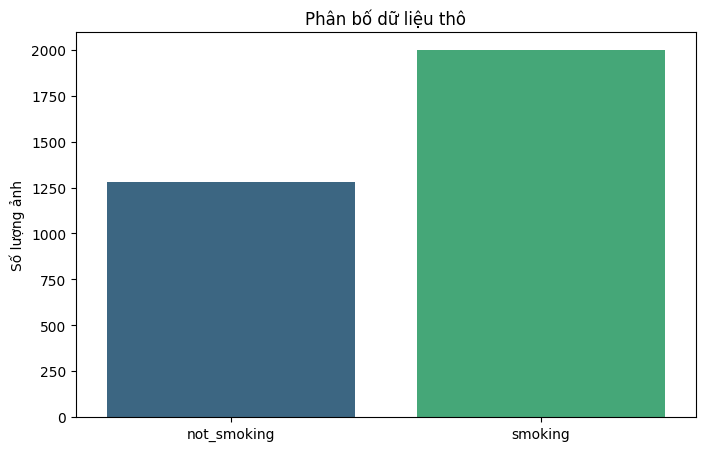

In [2]:
class_counts = {}
for cls in CLASSES:
    cls_path = os.path.join(RAW_DATA_DIR, cls)
    if os.path.exists(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))
    else:
        class_counts[cls] = 0
        print(f"[CẢNH BÁO] Không tìm thấy thư mục: {cls_path}")

plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis', hue=list(class_counts.keys()), legend=False)
plt.title('Phân bố dữ liệu thô')
plt.ylabel('Số lượng ảnh')
plt.show()

## 2 · Loại bỏ Ảnh Trùng (Deduplication)

> Sử dụng **mã băm MD5** trên nội dung nhị phân của từng file ảnh.  
> Hai ảnh giống nhau về pixel sẽ có cùng hash → chỉ giữ lại một bản.  
>
> 

In [3]:
def get_unique_images(raw_dir, classes):
    hashes = set()
    unique_samples = []
    stats = {'valid': 0, 'duplicate': 0, 'error': 0}

    for cls in classes:
        paths = glob.glob(os.path.join(raw_dir, cls, "*"))
        for path in tqdm(paths, desc=f"Đang quét lớp {cls}"):
            if not path.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            try:
                with open(path, 'rb') as f:
                    f_hash = hashlib.md5(f.read()).hexdigest()
                
                if f_hash in hashes:
                    stats['duplicate'] += 1
                    continue
                
                hashes.add(f_hash)
                unique_samples.append((path, cls))
                stats['valid'] += 1
            except:
                stats['error'] += 1
    
    print(f"Thống kê: {stats['valid']} ảnh duy nhất, {stats['duplicate']} ảnh trùng, {stats['error']} lỗi.")
    return unique_samples

valid_samples = get_unique_images(RAW_DATA_DIR, CLASSES)

Đang quét lớp smoking: 100%|██████████| 1996/1996 [00:33<00:00, 58.88it/s]

Thống kê: 2879 ảnh duy nhất, 375 ảnh trùng, 0 lỗi.


## 3 · Ước lượng & Lọc Nhiễu (Noise Estimation)

> Tính **sigma ước lượng** của nhiễu Gaussian trên ảnh grayscale bằng `skimage.restoration.estimate_sigma`.  
> Ảnh có **σ > 15.0** bị loại bỏ.
>
>  **Lý do:** Ảnh nhiễu cao khiến mô hình học các artifact thay vì đặc trưng thực sự của đối tượng (điếu thuốc, khói).


In [4]:
def filter_noisy_images(samples, threshold=15.0):
    clean_samples = []
    for path, cls in tqdm(samples, desc="Lọc nhiễu"):
        img = cv2.imread(path)
        if img is None: continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        sigma = estimate_sigma(gray)
        if sigma <= threshold:
            clean_samples.append((path, cls))
    print(f"Giữ lại: {len(clean_samples)}/{len(samples)} ảnh đạt chất lượng.")
    return clean_samples

if valid_samples:
    valid_samples = filter_noisy_images(valid_samples)

Lọc nhiễu:  42%|████▏     | 1223/2879 [04:06<02:07, 13.04it/s]d:\Dev\smoker_detection\venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Dev\smoker_detection\venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Lọc nhiễu: 100%|██████████| 2879/2879 [05:27<00:00,  8.78it/s] 

Giữ lại: 2861/2879 ảnh đạt chất lượng.


## 4 · Tiền xử lý Nâng cao — CLAHE & Letterbox (224 × 224)

### CLAHE _(Contrast Limited Adaptive Histogram Equalization)_

- Áp dụng trên kênh **L** của không gian màu **LAB** (tách độ sáng khỏi màu sắc).
- Tham số: `clipLimit=2.0`, `tileGridSize=(8, 8)` — cân bằng tương phản cục bộ, làm nổi bật chi tiết điếu thuốc/khói mà không bão hòa màu.

### Letterbox Resize

- Thay đổi kích thước ảnh về **224 × 224** trong khi **giữ nguyên tỉ lệ khung hình** bằng padding màu đen.
- **Lý do:** Tránh méo hình ảnh — quan trọng khi vật thể nhỏ (đầu điếu thuốc) cần được bảo toàn tỉ lệ.

> **Output:** Tập ảnh đã qua tiền xử lý được lưu vào `dataset/processed_dataset/`


In [5]:
def advanced_preprocess(image_path, target_size):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None: return None
    
    # 1. CLAHE
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    img_enhanced = cv2.cvtColor(cv2.merge((cl,a,b)), cv2.COLOR_LAB2BGR)
    
    # 2. Letterbox
    h, w = img_enhanced.shape[:2]
    scale = min(target_size[0]/h, target_size[1]/w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img_enhanced, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)

    delta_w = target_size[1] - new_w
    delta_h = target_size[0] - new_h
    top, bottom = delta_h//2, delta_h-(delta_h//2)
    left, right = delta_w//2, delta_w-(delta_w//2)

    final_img = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return final_img

# Thực thi và lưu kết quả
if not os.path.exists(PROCESSED_DATA_DIR):
    os.makedirs(PROCESSED_DATA_DIR)

for cls in CLASSES:
    os.makedirs(os.path.join(PROCESSED_DATA_DIR, cls), exist_ok=True)

for path, cls in tqdm(valid_samples, desc="Đang xử lý & lưu"):
    processed = advanced_preprocess(path, TARGET_SIZE)
    if processed is not None:
        fname = os.path.basename(path).split('.')[0] + ".jpg"
        cv2.imwrite(os.path.join(PROCESSED_DATA_DIR, cls, fname), processed)

Đang xử lý & lưu: 100%|██████████| 2861/2861 [01:11<00:00, 39.76it/s] 
